In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Telco Churn dataset (download from Kaggle)
# New (after curl download)
df = pd.read_csv(r'C:\Users\ragin\customer-churn-analysis\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


print(df.shape)
print(df['Churn'].value_counts())
df['Churn'].value_counts(normalize=True).plot(kind='bar', color=['green','red'])
plt.title('Churn Rate')
plt.show()

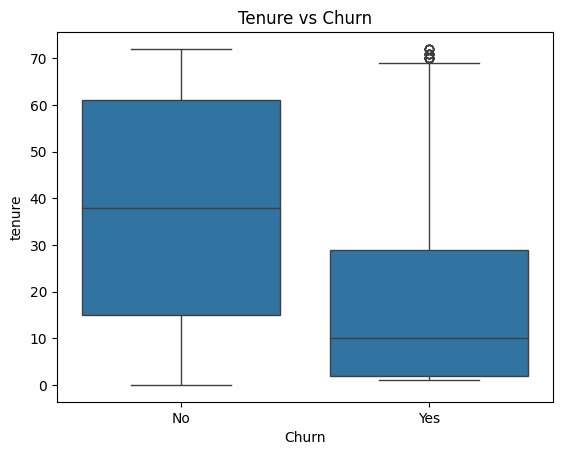

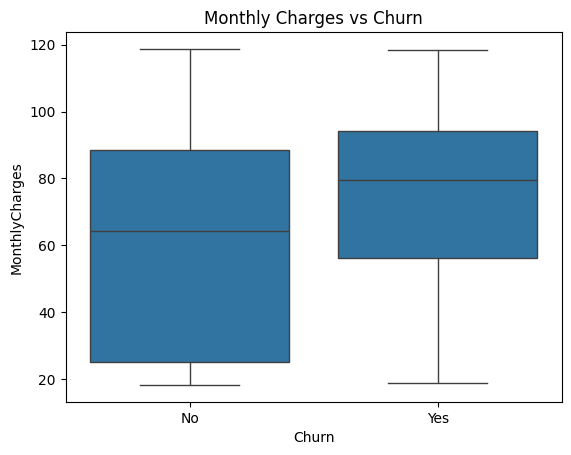

In [3]:
# Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

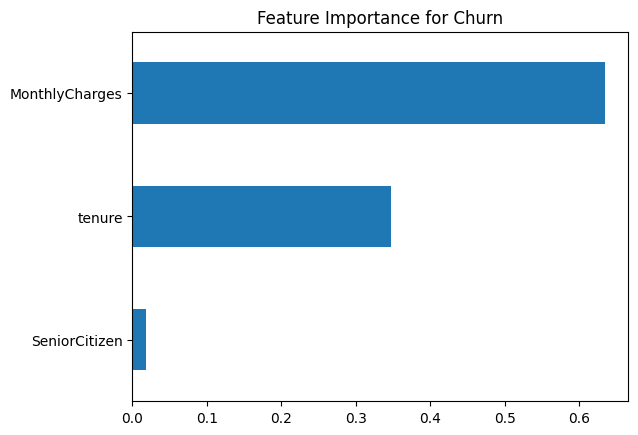

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df2 = df.copy()
df2['Churn'] = (df2['Churn'] == 'Yes').astype(int)
df2 = df2.select_dtypes(include=['number']).dropna()

X = df2.drop('Churn', axis=1)
y = df2['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance for Churn')
plt.show()

In [6]:
# Key Findings & Recommendations
# - Customers with low tenure churn more -> Offer early loyalty rewards
# - High monthly charges correlate with churn -> Introduce flexible plans  
# - Customers with month-to-month contracts churn most -> Promote annual plans

print("Key Findings & Recommendations")
print("- Customers with low tenure churn more -> Offer early loyalty rewards")
print("- High monthly charges correlate with churn -> Introduce flexible plans")
print("- Customers with month-to-month contracts churn most -> Promote annual plans")

Key Findings & Recommendations
- Customers with low tenure churn more -> Offer early loyalty rewards
- High monthly charges correlate with churn -> Introduce flexible plans
- Customers with month-to-month contracts churn most -> Promote annual plans
